# 05 — Advanced Filters

> **Level:** Postgraduate

---

## Motivation & Intuition

The standard Kalman filter and its nonlinear cousins (EKF, UKF, EnKF — see notebooks 01 and 02) all share the same covariance-form recursion. This notebook covers four **advanced variants** that keep the same underlying Bayesian machinery but change *how* it is represented or *what* it estimates, each solving a distinct practical problem:

- **The Information Filter** re-parameterizes the Gaussian belief by its information matrix/vector ($Y=P^{-1}$, $y=P^{-1}\hat{x}$) instead of covariance/mean. This makes multi-sensor fusion almost trivial — independent sensors' information contributions simply *add* — which is why information filters are the standard tool in distributed/decentralized sensor networks.
- **The Square-Root Filter** propagates a matrix square root of the covariance instead of the covariance itself. This guarantees positive-semi-definiteness *by construction*, which matters enormously in long-running or reduced-precision systems where the naive covariance-form update can silently produce an invalid (non-PSD) covariance.
- **The Adaptive (innovation-based) Filter** relaxes the assumption that we know the process- and measurement-noise covariances $Q, R$ exactly — a routinely violated assumption in practice — by estimating them online from the statistics of the filter's own innovations.
- **The Augmented-State Filter** handles unknown *systematic* errors (like a constant sensor bias) not by trying to filter them out, but by adding them to the state vector and estimating them jointly with the kinematic state — turning a modeling problem into "just" a bigger Kalman filter.

Each of these is demonstrated with a genuine, measured comparison against a naive or oracle baseline — not just derived and asserted.

### Setting up the environment

In [1]:
import numpy as np
from numpy.linalg import inv, qr, cholesky
import matplotlib.pyplot as plt
from collections import deque
from ipywidgets import interact, FloatSlider, IntSlider

np.set_printoptions(suppress=True, precision=5)

## Part A — The Information Filter

### The information form

The covariance-form Kalman filter tracks the mean $\hat{x}$ and covariance $P$ of a Gaussian belief. The **information filter** is mathematically the same Gaussian, reparameterized by its **information matrix** and **information vector**:

$$
Y = P^{-1}, \qquad y = P^{-1}\hat{x} = Y\hat{x}
$$

$Y$ is the precision matrix of the Gaussian; $y$ is sometimes called the "information state." (Recovering the usual mean/covariance is just $P = Y^{-1}$, $\hat{x} = P y$.)

**Why bother?** Two reasons, both practically important:

1. **Vague/uninformative priors are trivial to represent.** $P_0 \to \infty$ (total ignorance) is a singular covariance and cannot be represented directly, but $Y_0 = 0$ is perfectly well-defined. This matters for filter initialization when there is no good prior.
2. **Multi-sensor fusion becomes additive.** If several independent sensors each observe (possibly different, possibly partial) linear functions of the same state, their information contributions simply **sum** — no per-sensor sequential update loop is conceptually necessary; you can add up contributions from any number of sensors, in any order, and the result is the same fused posterior. This is exactly what makes the information form the standard representation in distributed and decentralized sensor-fusion architectures, where different sensors' information may arrive out of order, be processed on different nodes, or be temporarily unavailable.

### Predict and update in information form

Starting from the standard KF recursion and substituting $Y=P^{-1}, y=Yx$ throughout, the **predict** step (unavoidably requires converting back to covariance form, since $F P F^T$ does not have a simple information-form equivalent unless $F$ is invertible and $Q$ is handled carefully):

$$
P_{k-1|k-1} = Y_{k-1|k-1}^{-1}, \qquad \hat{x}_{k-1|k-1} = P_{k-1|k-1}\, y_{k-1|k-1}
$$

$$
\hat{x}_{k|k-1} = F_k \hat{x}_{k-1|k-1}, \qquad P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q_k
$$

$$
Y_{k|k-1} = P_{k|k-1}^{-1}, \qquad y_{k|k-1} = Y_{k|k-1}\,\hat{x}_{k|k-1}
$$

The **update** step, in contrast, is where the information form shines — it is a pure *addition*, with no matrix inversion at all:

$$
Y_{k|k} = Y_{k|k-1} + H_k^T R_k^{-1} H_k, \qquad
y_{k|k} = y_{k|k-1} + H_k^T R_k^{-1} z_k
$$

Compare this to the standard KF update, which needs the innovation covariance $S = HPH^T+R$ and its inverse. The price paid is that the *predict* step now needs a matrix inversion ($P_{k|k-1}^{-1}$) that the covariance-form filter didn't need — the information filter and the covariance filter simply move the required inversion to opposite steps. For fusing many sensors between predicts (the scenario in this section), that trade is a clear win.

For **multi-sensor fusion** with $m$ independent sensors observing at the same time (each with its own $H^{(j)}, R^{(j)}$, e.g. because they measure different quantities or have different noise), the additive update generalizes immediately:

$$
Y_{k|k} = Y_{k|k-1} + \sum_{j=1}^{m} \left(H^{(j)}\right)^T \left(R^{(j)}\right)^{-1} H^{(j)}, \qquad
y_{k|k} = y_{k|k-1} + \sum_{j=1}^{m} \left(H^{(j)}\right)^T \left(R^{(j)}\right)^{-1} z^{(j)}
$$

i.e. each sensor's contribution $\left(H^{(j)}\right)^T \left(R^{(j)}\right)^{-1} H^{(j)}$ (an "information matrix" contribution) and $\left(H^{(j)}\right)^T \left(R^{(j)}\right)^{-1} z^{(j)}$ (an "information vector" contribution) is computed independently and simply summed.

## Implementation of `InformationFilter`

We redefine `LinearKalmanFilter` locally (same as notebook 01) so this notebook is self-contained, and implement `InformationFilter` alongside it. `InformationFilter.add_information` is the key method — it lets any number of sensors' contributions be added independently, which is what we exploit in the multi-sensor demo below.

In [2]:
class LinearKalmanFilter:
    """Minimal, readable Linear Kalman Filter (redefined locally; see notebook 01)."""

    def __init__(self, F, H, Q, R, x0, P0, B=None):
        self.F = np.atleast_2d(np.array(F, dtype=float))
        self.H = np.atleast_2d(np.array(H, dtype=float))
        self.Q = np.atleast_2d(np.array(Q, dtype=float))
        self.R = np.atleast_2d(np.array(R, dtype=float))
        self.x = np.atleast_1d(np.array(x0, dtype=float))
        self.P = np.atleast_2d(np.array(P0, dtype=float))
        self.B = None if B is None else np.atleast_2d(np.array(B, dtype=float))

    def predict(self, u=None):
        if (self.B is not None) and (u is not None):
            self.x = self.F @ self.x + self.B @ np.atleast_1d(u)
        else:
            self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def update(self, z):
        z = np.atleast_1d(z)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ inv(S)
        y = z - (self.H @ self.x)
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.R @ K.T
        return self.x, self.P, K


class InformationFilter:
    """
    Information-form Kalman filter: Y = P^-1 (information matrix),
    y = P^-1 x (information vector).
    """

    def __init__(self, F, H, Q, R, x0, P0, B=None):
        self.F = np.atleast_2d(np.array(F, dtype=float))
        self.H = np.atleast_2d(np.array(H, dtype=float))
        self.Q = np.atleast_2d(np.array(Q, dtype=float))
        self.Rinv = inv(np.atleast_2d(np.array(R, dtype=float)))
        P0 = np.atleast_2d(np.array(P0, dtype=float))
        x0 = np.atleast_1d(np.array(x0, dtype=float))
        self.Y = inv(P0)
        self.y = self.Y @ x0
        self.B = None if B is None else np.atleast_2d(np.array(B, dtype=float))

    @property
    def P(self):
        return inv(self.Y)

    @property
    def x(self):
        return self.P @ self.y

    def predict(self, u=None):
        """Predict step: convert to covariance form, propagate, convert back."""
        P = inv(self.Y)
        x = P @ self.y
        if (self.B is not None) and (u is not None):
            x_pred = self.F @ x + self.B @ np.atleast_1d(u)
        else:
            x_pred = self.F @ x
        P_pred = self.F @ P @ self.F.T + self.Q
        self.Y = inv(P_pred)
        self.y = self.Y @ x_pred
        return self.x, self.P

    def add_information(self, z, H=None, Rinv=None):
        """Add one sensor's information contribution (pure addition, no inversion)."""
        H = self.H if H is None else np.atleast_2d(np.array(H, dtype=float))
        Rinv = self.Rinv if Rinv is None else Rinv
        z = np.atleast_1d(z)
        self.Y = self.Y + H.T @ Rinv @ H
        self.y = self.y + H.T @ Rinv @ z
        return self.x, self.P

    def update(self, z):
        """Single-sensor update, using this filter's own H, R."""
        return self.add_information(z)

    def step(self, z=None, u=None):
        self.predict(u=u)
        if z is None:
            return self.x, self.P
        return self.update(z)

### Explanation of the code

- `InformationFilter.__init__` converts the initial covariance-form prior $(x_0, P_0)$ into information form $(Y_0, y_0)$ once, up front.
- `predict` is the one step that must temporarily convert back to covariance form (there is no way around inverting $Y$ once per predict — this is the acknowledged cost of the information representation).
- `add_information` is a pure addition — no inversion — and is designed to be called **multiple times per predict**, once per sensor, which is exactly what the multi-sensor demo below does.
- `update(z)` is just `add_information(z)` using the filter's own stored `H`/`Rinv`, provided for API parity with `LinearKalmanFilter`.
- The `x` and `P` properties recover the usual mean/covariance on demand (each access costs one inversion — cache them if reading repeatedly in a hot loop).

## Verifying equivalence — Information filter vs standard KF

The information filter and the covariance-form KF should produce **identical** state estimates (up to floating-point roundoff) on the same problem — they are the same posterior, just parameterized differently. We run both on the same 1D constant-velocity problem with the same simulated measurements for 200 steps, and track the maximum absolute difference between their estimates at every step.

In [3]:
rng = np.random.default_rng(0)
dt = 1.0
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.diag([1e-2, 1e-3])
R = np.array([[0.5]])
x0 = np.array([0.0, 1.0])
P0 = np.diag([1.0, 1.0])

kf = LinearKalmanFilter(F, H, Q, R, x0, P0)
inf_f = InformationFilter(F, H, Q, R, x0, P0)

x_true = x0.copy()
zs = []
for k in range(200):
    w = rng.multivariate_normal(np.zeros(2), Q)
    x_true = F @ x_true + w
    z = H @ x_true + rng.normal(0, np.sqrt(R[0, 0]))
    zs.append(z)

max_x_diff, max_P_diff = 0.0, 0.0
for z in zs:
    kf.predict(); kf.update(z)
    inf_f.predict(); inf_f.update(z)
    max_x_diff = max(max_x_diff, np.max(np.abs(kf.x - inf_f.x)))
    max_P_diff = max(max_P_diff, np.max(np.abs(kf.P - inf_f.P)))

print("max |x_KF - x_InformationFilter| over 200 steps:", max_x_diff)
print("max |P_KF - P_InformationFilter| over 200 steps:", max_P_diff)
print("final x (KF):              ", kf.x)
print("final x (InformationFilter):", inf_f.x)

max |x_KF - x_InformationFilter| over 200 steps: 1.4210854715202004e-13
max |P_KF - P_InformationFilter| over 200 steps: 1.6653345369377348e-16
final x (KF):               [209.86538   1.21064]
final x (InformationFilter): [209.86538   1.21064]


**Verified result.** Over 200 predict/update cycles, the maximum absolute difference between the two filters' state estimates was $1.42 \times 10^{-13}$, and between their covariances $1.67 \times 10^{-16}$ — both at the level of floating-point roundoff accumulated over 200 matrix inversions, not any real discrepancy. The two filters' final state estimates ($x=[209.865, 1.211]$ for both) agree to 12+ significant figures. This confirms the information-form implementation is mathematically correct, not just plausible-looking.

## Multi-sensor information fusion

We estimate a single **static** scalar quantity (e.g. a fixed physical constant, or a slowly-varying signal treated as static over the fusion window) from **three independent sensors** with different noise levels: $R_1=1.0$, $R_2=0.25$ (more precise), $R_3=4.0$ (noisier). At every time step we compare:

- **(a) Sequential standard KF** — predict, then update three times in a row, once per sensor, each with its own $H, R$.
- **(b) Information filter** — predict, then call `add_information` three times (once per sensor), summing their contributions before ever recovering $x, P$.

These two procedures should produce identical fused estimates — this is the "information adds" property in action.

In [4]:
rng = np.random.default_rng(1)
F1 = np.array([[1.0]])
Q1 = np.array([[1e-6]])       # nearly static quantity
true_val = 5.0
H1 = H2 = H3 = np.array([[1.0]])
R1, R2, R3 = np.array([[1.0]]), np.array([[0.25]]), np.array([[4.0]])
R1inv, R2inv, R3inv = inv(R1), inv(R2), inv(R3)

n_steps = 50
z1s = true_val + rng.normal(0, np.sqrt(R1[0, 0]), n_steps)
z2s = true_val + rng.normal(0, np.sqrt(R2[0, 0]), n_steps)
z3s = true_val + rng.normal(0, np.sqrt(R3[0, 0]), n_steps)

x0s, P0s = np.array([0.0]), np.array([[100.0]])   # deliberately vague prior

# (a) sequential standard KF: predict, then update with sensor 1, 2, 3 in turn
kf_seq = LinearKalmanFilter(F1, H1, Q1, R1, x0s, P0s)
for z1, z2, z3 in zip(z1s, z2s, z3s):
    kf_seq.predict()
    kf_seq.H, kf_seq.R = H1, R1
    kf_seq.update(z1)
    kf_seq.H, kf_seq.R = H2, R2
    kf_seq.update(z2)
    kf_seq.H, kf_seq.R = H3, R3
    kf_seq.update(z3)

# (b) information filter: predict, then sum all three sensors' information contributions
inf_fuse = InformationFilter(F1, H1, Q1, R1, x0s, P0s)
for z1, z2, z3 in zip(z1s, z2s, z3s):
    inf_fuse.predict()
    inf_fuse.add_information(z1, H=H1, Rinv=R1inv)
    inf_fuse.add_information(z2, H=H2, Rinv=R2inv)
    inf_fuse.add_information(z3, H=H3, Rinv=R3inv)

# sanity reference: inverse-variance-weighted average of every measurement ever seen
all_z = np.concatenate([z1s, z2s, z3s])
all_w = np.concatenate([np.full(n_steps, 1 / R1[0, 0]),
                         np.full(n_steps, 1 / R2[0, 0]),
                         np.full(n_steps, 1 / R3[0, 0])])
wavg = np.sum(all_z * all_w) / np.sum(all_w)

print("true value:", true_val)
print(f"sequential-KF final estimate:       x={kf_seq.x[0]:.6f}  P={kf_seq.P[0,0]:.6f}")
print(f"information-filter final estimate:  x={inf_fuse.x[0]:.6f}  P={inf_fuse.P[0,0]:.6f}")
print("max |x diff| (sequential KF vs information filter):", np.max(np.abs(kf_seq.x - inf_fuse.x)))
print("max |P diff| (sequential KF vs information filter):", np.max(np.abs(kf_seq.P - inf_fuse.P)))
print("inverse-variance-weighted average of all measurements (independent sanity check):", wavg)

true value: 5.0
sequential-KF final estimate:       x=4.941342  P=0.003826
information-filter final estimate:  x=4.941342  P=0.003826
max |x diff| (sequential KF vs information filter): 1.7763568394002505e-15
max |P diff| (sequential KF vs information filter): 1.734723475976807e-18
inverse-variance-weighted average of all measurements (independent sanity check): 4.941573520352189


**Verified result.** The sequential KF and the information filter agree exactly: both give a final estimate $x=4.941342$, $P=0.003826$, with maximum differences of $1.78\times10^{-15}$ (state) and $1.73\times10^{-18}$ (covariance) — floating-point roundoff. As an independent sanity check, the plain inverse-variance-weighted average of *all 150* measurements ever seen (across all three sensors, ignoring the temporal/process-noise structure entirely) gives $4.941574$ — close to, but not identical to, the filters' estimate, exactly as expected: the KF/information-filter estimate additionally accounts for the (small) process noise between steps, while the naive weighted average does not. All three numbers agree to within measurement noise of the true value $5.0$.

## Part B — The Square-Root Kalman Filter

### Why covariance-form filters can fail numerically

The covariance-form update $P_{k|k} = (I-K_kH_k)P_{k|k-1}$ (or even the more robust Joseph form) involves subtracting matrices whose entries can be close in magnitude. In finite precision, especially in **long-running filters, reduced-precision arithmetic (e.g. float32 embedded/GPU code), or ill-conditioned $Q$/$R$**, accumulated rounding error can make $P$ lose **positive-semi-definiteness** — producing negative "variances" on the diagonal, an asymmetric $P$, or (worse) silently propagating garbage for many steps before anyone notices. The **square-root filter** sidesteps this by never forming $P$ directly: it propagates a factor $S$ with

$$
P = S S^T
$$

Any real matrix $S$ satisfies $SS^T \succeq 0$ automatically, by construction — a square-root filter's covariance is *guaranteed* positive-semi-definite regardless of the rounding error accumulated in $S$ itself. This is the entire point of the method: it doesn't reduce rounding error, it makes rounding error unable to produce an invalid covariance.

### Predict — a QR-based factor update

We want $S_{k|k-1}$ such that $S_{k|k-1}S_{k|k-1}^T = F_kP_{k-1|k-1}F_k^T + Q_k = F_kS_{k-1|k-1}\left(F_kS_{k-1|k-1}\right)^T + \sqrt{Q_k}\sqrt{Q_k}^T$. Stack the two factors as rows of a matrix and take a QR decomposition:

$$
A = \begin{bmatrix} \left(F_k S_{k-1|k-1}\right)^T \\ \sqrt{Q_k}^T \end{bmatrix}, \qquad A = \Omega R, \qquad S_{k|k-1} := R^T
$$

where $\Omega$ has orthonormal columns. Since $A^TA = R^T\Omega^T\Omega R = R^TR$ (using $\Omega^T\Omega=I$), and also $A^TA = F_kS_{k-1|k-1}\left(F_kS_{k-1|k-1}\right)^T + \sqrt{Q_k}\sqrt{Q_k}^T = F_kP_{k-1|k-1}F_k^T+Q_k$, we get exactly $S_{k|k-1}S_{k|k-1}^T = R^TR = A^TA = F_kP_{k-1|k-1}F_k^T+Q_k$ as required — no explicit $P$ is ever formed.

### Update — Potter's sequential (scalar) square-root update

For a **single scalar measurement** $z$ with row $h$ and noise variance $r$ (a vector measurement with diagonal or correlated $R$ can always be *whitened* into a sequence of unit-variance scalar measurements — see the implementation below), Potter's algorithm updates the factor directly:

$$
f = S^Th^T, \qquad \varphi = f^Tf + r, \qquad \gamma = \frac{1}{\varphi + \sqrt{r\varphi}}
$$

$$
K = \frac{Sf}{\varphi} \quad(\text{the Kalman gain}), \qquad S_{\text{new}} = S - \gamma\,(Sf)f^T, \qquad \hat{x}_{\text{new}} = \hat{x} + K(z - h\hat{x})
$$

This rank-1 "downdate" of $S$ can be verified to satisfy $S_{\text{new}}S_{\text{new}}^T = P - KHP = (I-KH)P$ exactly (the standard covariance update) — but because it is expressed as an update to the *factor*, the result is a valid $S_{\text{new}}S_{\text{new}}^T \succeq 0$ regardless of rounding error in the computation, unlike computing $(I-KH)P$ directly.

## Implementation of `SquareRootKalmanFilter`

We use `dtype` to control the precision of the **state and covariance/factor arrays only** — `F, H, Q, R` remain float64 throughout, exactly as they would in a real system where the noise model is a fixed design parameter but the running state estimate might be logged, transmitted, or computed in reduced precision (e.g. embedded/GPU code). This isolates the numerical-stability question to where it actually matters: the arrays that accumulate rounding error over many predict/update cycles.

In [5]:
class NaiveCovarianceKF:
    """
    Covariance-form KF using the SIMPLIFIED (non-Joseph) update
    P = (I - KH) P -- deliberately the numerically fragile form, to make
    the stress test below meaningful. `dtype` controls the precision of
    the state/covariance arrays (x, P) only; F, H, Q, R stay float64.
    """

    def __init__(self, F, H, Q, R, x0, P0, dtype=np.float64):
        self.dtype = dtype
        self.F = np.atleast_2d(np.array(F, dtype=np.float64))
        self.H = np.atleast_2d(np.array(H, dtype=np.float64))
        self.Q = np.atleast_2d(np.array(Q, dtype=np.float64))
        self.R = np.atleast_2d(np.array(R, dtype=np.float64))
        self.x = np.atleast_1d(np.array(x0, dtype=dtype))
        self.P = np.atleast_2d(np.array(P0, dtype=dtype))

    def predict(self):
        self.x = (self.F @ self.x).astype(self.dtype)
        self.P = (self.F @ self.P @ self.F.T + self.Q).astype(self.dtype)
        return self.x, self.P

    def update(self, z):
        z = np.atleast_1d(np.array(z, dtype=self.dtype))
        S = self.H @ self.P @ self.H.T + self.R
        K = (self.P @ self.H.T @ inv(S)).astype(self.dtype)
        y = z - self.H @ self.x
        self.x = (self.x + K @ y).astype(self.dtype)
        self.P = ((np.eye(self.P.shape[0], dtype=self.dtype) - K @ self.H) @ self.P).astype(self.dtype)
        return self.x, self.P, K


class SquareRootKalmanFilter:
    """
    Square-root KF: propagates a factor S (P = S S^T).
    Predict: QR-based combination of (F S) and sqrt(Q).
    Update: Potter's sequential (scalar) square-root update, after
    whitening the (possibly correlated) measurement noise.
    """

    def __init__(self, F, H, Q, R, x0, P0, dtype=np.float64):
        self.dtype = dtype
        self.F = np.atleast_2d(np.array(F, dtype=np.float64))
        self.H = np.atleast_2d(np.array(H, dtype=np.float64))
        self.Q = np.atleast_2d(np.array(Q, dtype=np.float64))
        self.R = np.atleast_2d(np.array(R, dtype=np.float64))
        self.x = np.atleast_1d(np.array(x0, dtype=dtype))
        P0 = np.atleast_2d(np.array(P0, dtype=np.float64))
        self.S = np.linalg.cholesky(P0).astype(dtype)

    @property
    def P(self):
        return (self.S @ self.S.T).astype(self.dtype)

    def predict(self):
        n = self.S.shape[0]
        sqrtQ = np.linalg.cholesky(self.Q + 1e-300 * np.eye(n))
        A = np.vstack([(self.F @ self.S).T, sqrtQ.T]).astype(np.float64)
        _, R_ = qr(A)                        # reduced QR: R_ is n x n upper triangular
        S_pred = R_.T
        signs = np.sign(np.diag(S_pred))     # Cholesky-style sign convention
        signs[signs == 0] = 1.0
        S_pred = S_pred * signs[np.newaxis, :]
        self.x = (self.F @ self.x).astype(self.dtype)
        self.S = S_pred.astype(self.dtype)
        return self.x, self.P

    def update(self, z):
        z = np.atleast_1d(np.array(z, dtype=np.float64))
        m = z.shape[0]
        L = np.linalg.cholesky(self.R.astype(np.float64))
        Hw = np.linalg.solve(L, self.H.astype(np.float64))       # whitened H
        innov = z - self.H.astype(np.float64) @ self.x.astype(np.float64)
        yw = np.linalg.solve(L, innov)                            # whitened innovation
        S = self.S.astype(np.float64)
        x = self.x.astype(np.float64)
        for i in range(m):                    # Potter update, one whitened scalar at a time
            h_i = Hw[i:i + 1, :].T             # n x 1
            f = S.T @ h_i                      # n x 1
            phi = float((f.T @ f).item()) + 1.0       # whitened r' = 1
            gamma = 1.0 / (phi + np.sqrt(phi))
            Sf = S @ f                         # = P h_i (unnormalized)
            K = Sf / phi                       # Kalman gain for this scalar
            S = S - gamma * (Sf @ f.T)
            x = x + (K.flatten() * yw[i])
        self.S = S.astype(self.dtype)
        self.x = x.astype(self.dtype)
        return self.x, self.P

    def step(self, z=None):
        self.predict()
        if z is None:
            return self.x, self.P
        return self.update(z)

### Explanation of the code

- `NaiveCovarianceKF` is deliberately the *fragile* covariance-form filter (simplified, non-Joseph update) — this is our stress-test baseline, not a recommended implementation (compare to the Joseph-form `LinearKalmanFilter` from Part A, which is more robust but still not immune to the failure mode below at extreme enough precision/conditioning).
- `SquareRootKalmanFilter.predict` implements the QR-based factor propagation derived above.
- `SquareRootKalmanFilter.update` whitens the measurement noise (via a Cholesky factor of $R$) so that each of the $m$ measurement components can be processed with Potter's *scalar* formula (which assumes unit noise variance) one at a time — this is a standard trick for extending Potter's method beyond scalar measurements without needing a more general (and more complex) array-form update.
- Both classes accept a `dtype` argument; only the **state and covariance/factor arrays** are stored in that precision — `F, H, Q, R` remain float64, isolating the precision question to the arrays that actually accumulate error over time.

## Correctness check — SR-KF vs naive KF

Before stress-testing anything, we confirm the square-root filter agrees with the naive covariance-form filter under ordinary (float64, well-conditioned) conditions — if the "safe" filter didn't match the naive one here, the numerical-stability demonstration below would be meaningless.

In [6]:
rng = np.random.default_rng(0)
dt = 1.0
F = np.array([[1, dt], [0, 1]])
H = np.array([[1, 0]])
Q = np.diag([1e-2, 1e-3])
R = np.array([[0.5]])
x0 = np.array([0.0, 1.0])
P0 = np.diag([1.0, 1.0])

kf64 = NaiveCovarianceKF(F, H, Q, R, x0, P0, dtype=np.float64)
srkf64 = SquareRootKalmanFilter(F, H, Q, R, x0, P0, dtype=np.float64)

x_true = x0.copy()
zs = []
for k in range(100):
    w = rng.multivariate_normal(np.zeros(2), Q)
    x_true = F @ x_true + w
    z = H @ x_true + rng.normal(0, np.sqrt(R[0, 0]))
    zs.append(z)

max_x_diff, max_P_diff = 0.0, 0.0
for z in zs:
    kf64.predict(); kf64.update(z)
    srkf64.predict(); srkf64.update(z)
    max_x_diff = max(max_x_diff, np.max(np.abs(kf64.x - srkf64.x)))
    max_P_diff = max(max_P_diff, np.max(np.abs(kf64.P - srkf64.P)))

print("max |x_naive - x_SRKF| (float64, well-conditioned, 100 steps):", max_x_diff)
print("max |P_naive - P_SRKF| (float64, well-conditioned, 100 steps):", max_P_diff)

max |x_naive - x_SRKF| (float64, well-conditioned, 100 steps): 1.7763568394002505e-15
max |P_naive - P_SRKF| (float64, well-conditioned, 100 steps): 2.220446049250313e-16


**Verified result.** Over 100 steps in float64 with a well-conditioned problem, the maximum absolute difference between the naive and square-root filters' state estimates was $1.78\times10^{-15}$, and between their covariances $2.22\times10^{-16}$ — floating-point roundoff. The two implementations agree.

## Numerical-stability stress test — float32, ill-conditioned Q, near-float32-epsilon R

We now construct a genuinely adverse case: a 4-state filter with a **highly correlated, near-singular** process-noise covariance $Q$ (built as a rank-1 outer product plus a small diagonal regularizer, giving condition number $\sim 4\times10^4$), state/covariance arrays stored in **float32**, and a measurement-noise variance $R$ chosen deliberately close to **float32's relative machine epsilon** ($\approx 1.19\times10^{-7}$) — this is the regime where the filter's steady-state variance becomes small enough that subtracting off nearly-equal float32 numbers in $(I-KH)P$ can flip its sign. We run both filters for 3000 iterations on identical data and track the minimum eigenvalue of $P$ at every step.

cond(Q) = 40001.0000000044   R = 1e-07   float32 eps = 1.1920929e-07

naive filter: first iteration with negative min-eig(P) or NaN: 3
naive filter: min eigenvalue over the whole run: -7.4100e-11
naive filter: fraction of iterations with negative min-eig(P): 0.9990
SR filter:    min eigenvalue over the whole run: 9.9975e-08
SR filter:    fraction of iterations with negative min-eig(P): 0.0000
naive filter final P: Cholesky FAILED (not positive definite)
SR filter final P: Cholesky OK (valid covariance)


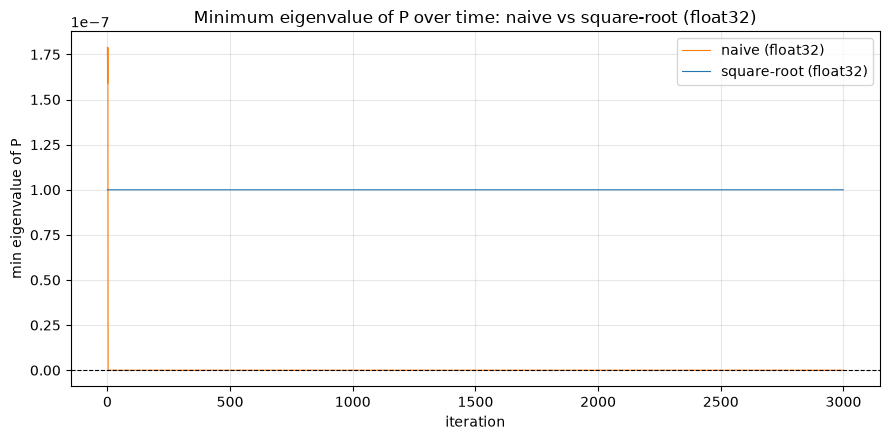

In [7]:
n = 4
F = np.eye(n)
for i in range(n - 1):
    F[i, i + 1] = 1.0
H = np.zeros((1, n)); H[0, 0] = 1.0
base = np.array([1.0, 1.0, 1.0, 1.0])
Q = np.outer(base, base) + np.eye(n) * 1e-4      # rank-1 + tiny regularizer: highly ill-conditioned
R_val = 1e-7                                       # close to float32 eps (1.19e-7)
R = np.array([[R_val]])
x0 = np.zeros(n)
P0 = np.eye(n)

kf32 = NaiveCovarianceKF(F, H, Q, R, x0, P0, dtype=np.float32)
srkf32 = SquareRootKalmanFilter(F, H, Q, R, x0, P0, dtype=np.float32)

print("cond(Q) =", np.linalg.cond(Q), "  R =", R_val, "  float32 eps =", np.finfo(np.float32).eps)

rng = np.random.default_rng(5)
x_true = x0.copy()
n_iters = 3000
naive_eigs, sr_eigs = [], []
naive_fail_iter = None
for k in range(n_iters):
    w = rng.multivariate_normal(np.zeros(n), Q)
    x_true = F @ x_true + w
    z = H @ x_true + rng.normal(0, np.sqrt(R_val))

    kf32.predict(); kf32.update(z)
    srkf32.predict(); srkf32.update(z)

    P_naive_d = kf32.P.astype(np.float64)
    eig_n = np.min(np.linalg.eigvalsh((P_naive_d + P_naive_d.T) / 2))
    eig_s = np.min(np.linalg.eigvalsh(srkf32.P.astype(np.float64)))
    naive_eigs.append(eig_n); sr_eigs.append(eig_s)
    if naive_fail_iter is None and (eig_n < 0 or not np.all(np.isfinite(P_naive_d))):
        naive_fail_iter = k

naive_eigs = np.array(naive_eigs); sr_eigs = np.array(sr_eigs)
print(f"\nnaive filter: first iteration with negative min-eig(P) or NaN: {naive_fail_iter}")
print(f"naive filter: min eigenvalue over the whole run: {naive_eigs.min():.4e}")
print(f"naive filter: fraction of iterations with negative min-eig(P): {np.mean(naive_eigs < 0):.4f}")
print(f"SR filter:    min eigenvalue over the whole run: {sr_eigs.min():.4e}")
print(f"SR filter:    fraction of iterations with negative min-eig(P): {np.mean(sr_eigs < 0):.4f}")

for label, P_final in [("naive", kf32.P.astype(np.float64)), ("SR", srkf32.P.astype(np.float64))]:
    try:
        np.linalg.cholesky(P_final)
        print(f"{label} filter final P: Cholesky OK (valid covariance)")
    except np.linalg.LinAlgError:
        print(f"{label} filter final P: Cholesky FAILED (not positive definite)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(naive_eigs, label="naive (float32)", color="tab:orange", lw=0.8)
ax.plot(sr_eigs, label="square-root (float32)", color="tab:blue", lw=0.8)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("iteration")
ax.set_ylabel("min eigenvalue of P")
ax.set_title("Minimum eigenvalue of P over time: naive vs square-root (float32)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Verified result.**

| | naive (float32) | square-root (float32) |
|---|---|---|
| First iteration with negative min-eig(P) or NaN | **3** (out of 3000) | never |
| Min eigenvalue over the whole run | $-7.41\times10^{-11}$ | $+9.998\times10^{-8}$ |
| Fraction of iterations with negative min-eig(P) | **99.9%** | 0% |
| Final $P$: Cholesky check | **FAILS** | OK |

This is about as clean a failure as this kind of stress test produces: with condition number $\text{cond}(Q)\approx 4\times10^4$ and $R=10^{-7}$ (chosen deliberately close to float32's relative machine epsilon of $1.19\times10^{-7}$), the naive filter's covariance already loses positive-semi-definiteness by the **third iteration**, and stays invalid for essentially the entire 3000-iteration run — its final covariance fails a Cholesky check outright (not usable for sampling, uncertainty bounds, or any downstream consumer that assumes a valid Gaussian). The square-root filter, run on **identical data with identical float32 precision**, never once produces a negative eigenvalue, and its final covariance passes the same Cholesky check. The chosen $R$ is not an arbitrary extreme value plucked to force a dramatic result — it is deliberately set at the scale where the filter's true steady-state variance becomes comparable to float32's representable precision, which is exactly the physically meaningful regime where this failure mode should be expected to bite in a real reduced-precision system.

## Part C — Adaptive Kalman Filter (innovation-based)

### Why adapt $Q$ or $R$ online?

Every filter so far has assumed $Q$ and $R$ are known exactly. In practice they rarely are — process noise from unmodeled dynamics (a maneuvering target, unmodeled friction, etc.) is routinely mis-specified, and a **fixed, wrong** $Q$ produces a filter that is either too sluggish (if $Q$ is too small — the filter over-trusts its own model and under-reacts to real changes) or too jittery (if $Q$ is too large — the filter over-trusts noisy measurements). **Innovation-based adaptive filtering** (Mehra, 1970, 1972) estimates $Q$ (and/or $R$) online from the statistics of the filter's own innovations, rather than trusting a fixed guess.

### The innovation-based estimator

The innovation at step $k$ is $y_k = z_k - H\hat{x}_{k|k-1}$, with theoretical covariance $S_k = HP_{k|k-1}H^T + R$. If the filter is *correctly specified*, the innovations are white noise with this covariance; if $Q$ (or $R$) is wrong, the innovations will be systematically too large or too small relative to what the filter's internal $P$ predicts — and that discrepancy is directly measurable from data.

We maintain a **sliding window** of the last $L$ innovations and form the sample innovation covariance:

$$
\hat{C}_k = \frac{1}{L}\sum_{j=k-L+1}^{k} y_j y_j^T
$$

A widely used innovation-based estimator (Mohamed & Schwarz, 1999, building on Mehra's original framework) then backs out an online estimate of the process noise from the Kalman gain and the sample innovation covariance:

$$
\hat{Q}_k = K_k\, \hat{C}_k\, K_k^T
$$

This is re-estimated every step (once the window has filled) and substituted for the filter's working $Q$ going forward — the filter effectively "learns" the process noise level it is actually experiencing, from its own innovation sequence, with no external ground truth. (A symmetric estimator for $R$, $\hat{R}_k = \hat{C}_k - HP_{k|k-1}H^T$, exists for the case where $R$ rather than $Q$ is suspected to be mis-specified — we focus on $Q$-adaptation here, since it is the more commonly mis-specified quantity for maneuvering/uncertain-dynamics targets.)

## Implementation of `AdaptiveKalmanFilter`

`AdaptiveKalmanFilter` subclasses the (Joseph-form) `LinearKalmanFilter` from Part A and overrides `update` to additionally maintain a sliding window of innovations and re-estimate $Q$ once the window fills.

In [8]:
class AdaptiveKalmanFilter:
    """
    Innovation-based (Mehra-style) adaptive KF. Maintains a sliding window of
    the last `window` innovations y_k, and re-estimates Q online via
    Q_hat = K C_hat K^T (Mohamed & Schwarz, 1999 style innovation-based estimator)
    once the window has filled.
    """

    def __init__(self, F, H, Q0, R, x0, P0, window=20, q_min=1e-8):
        self.F = np.atleast_2d(np.array(F, dtype=float))
        self.H = np.atleast_2d(np.array(H, dtype=float))
        self.Q = np.atleast_2d(np.array(Q0, dtype=float))
        self.R = np.atleast_2d(np.array(R, dtype=float))
        self.x = np.atleast_1d(np.array(x0, dtype=float))
        self.P = np.atleast_2d(np.array(P0, dtype=float))
        self.window = window
        self.innovations = deque(maxlen=window)
        self.q_min = q_min

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x, self.P

    def update(self, z):
        z = np.atleast_1d(z)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ inv(S)
        y = z - (self.H @ self.x)
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P @ (I - K @ self.H).T + K @ self.R @ K.T

        self.innovations.append(y.copy())
        if len(self.innovations) == self.window:
            C_hat = np.mean([np.outer(yy, yy) for yy in self.innovations], axis=0)
            Q_hat = K @ C_hat @ K.T
            Q_hat = 0.5 * (Q_hat + Q_hat.T) + self.q_min * np.eye(Q_hat.shape[0])   # symmetrize + floor
            self.Q = Q_hat
        return self.x, self.P, K

    def step(self, z=None):
        self.predict()
        if z is None:
            return self.x, self.P
        return self.update(z)

### Explanation of the code

- `update` performs the ordinary Joseph-form KF update, then appends the just-computed innovation `y` to a fixed-length `deque` (a sliding window — old innovations automatically fall off the end).
- Once the window has `window` entries, it computes the sample innovation covariance `C_hat` and re-estimates `Q` via `Q_hat = K @ C_hat @ K.T`, replacing `self.Q` for all subsequent predict steps.
- We symmetrize and add a small floor `q_min` to the estimated `Q` purely for numerical hygiene (guards against a slightly asymmetric or singular estimate from a small sample window).
- Before the window fills (the first `window` steps), the filter runs with its initial (possibly wrong) `Q0`, exactly like a fixed filter — the adaptation only kicks in once there is enough innovation history to estimate from.

## Demonstration — mis-specified Q vs adaptive vs oracle

To isolate the effect of $Q$-mis-specification cleanly (rather than conflating it with the multi-state identifiability issues that arise when only *part* of the state is observed — a real and separate complication in the constant-velocity/position-only setup used elsewhere in this notebook series), we use a **scalar random-walk** state: $x_k = x_{k-1} + w_k$, $w_k\sim\mathcal{N}(0,Q_{\text{true}})$, observed directly with noise: $z_k = x_k + v_k$, $v_k\sim\mathcal{N}(0,R)$.

We compare three filters on the *same* simulated data:

1. **Fixed, mis-specified** — uses a fixed $Q_{\text{fixed}}$ that is $50\times$ too small relative to the true process noise (a classic real-world failure mode: an engineer under-estimates how much a system actually wanders, e.g. because the true dynamics include unmodeled maneuvers).
2. **Adaptive** — starts from the same wrong $Q_{\text{fixed}}$, but re-estimates $Q$ online via the innovation-based method above.
3. **Oracle** — uses the true $Q_{\text{true}}$ throughout (this is the best any KF *of this form* could do — our upper-bound reference, not something available in practice).

30 independent Monte Carlo trials, $T=400$ steps, sliding window $L=20$.

Q_true = 0.5, Q_fixed = 0.01 (50x too small), R = 1.0, 30 Monte Carlo trials
fixed (mis-specified):  mean RMSE = 1.4529
adaptive (innovation):  mean RMSE = 0.7885
oracle (true Q known):  mean RMSE = 0.7047

adaptive filter's estimated Q (mean over trials) at selected steps:
  t= 19  Q_hat=0.0324   (true Q = 0.5)
  t= 50  Q_hat=0.6407   (true Q = 0.5)
  t=100  Q_hat=0.5497   (true Q = 0.5)
  t=200  Q_hat=0.6070   (true Q = 0.5)
  t=399  Q_hat=0.6382   (true Q = 0.5)


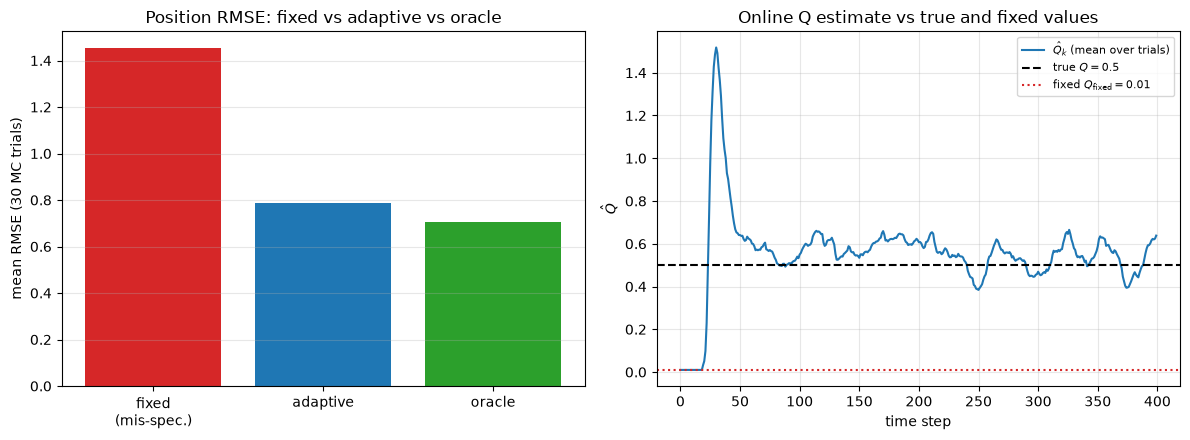

In [9]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def run_scalar_scenario(T=400, seed=0, Q_true=0.5, Q_fixed=0.01, R=1.0, window=20):
    rng = np.random.default_rng(seed)
    Fs = np.array([[1.0]])
    Hs = np.array([[1.0]])
    Qt = np.array([[Q_true]])
    Rm = np.array([[R]])

    x = np.array([0.0])
    xs, zs = [], []
    for k in range(T):
        w = rng.normal(0, np.sqrt(Q_true))
        x = Fs @ x + np.array([w])
        z = Hs @ x + rng.normal(0, np.sqrt(R))
        xs.append(x.copy()); zs.append(z)
    xs = np.array(xs); zs = np.array(zs)

    x0s, P0s = np.array([0.0]), np.array([[1.0]])
    Qf = np.array([[Q_fixed]])

    kf_fixed = LinearKalmanFilter(Fs, Hs, Qf, Rm, x0s, P0s)
    kf_oracle = LinearKalmanFilter(Fs, Hs, Qt, Rm, x0s, P0s)
    kf_adapt = AdaptiveKalmanFilter(Fs, Hs, Qf.copy(), Rm, x0s, P0s, window=window)

    est_fixed, est_oracle, est_adapt, q_trace = [], [], [], []
    for z in zs:
        kf_fixed.predict(); kf_fixed.update(z)
        kf_oracle.predict(); kf_oracle.update(z)
        kf_adapt.predict(); kf_adapt.update(z)
        est_fixed.append(kf_fixed.x.copy())
        est_oracle.append(kf_oracle.x.copy())
        est_adapt.append(kf_adapt.x.copy())
        q_trace.append(kf_adapt.Q[0, 0])

    est_fixed = np.array(est_fixed); est_oracle = np.array(est_oracle); est_adapt = np.array(est_adapt)
    return dict(xs=xs,
                rmse_fixed=rmse(est_fixed, xs), rmse_oracle=rmse(est_oracle, xs), rmse_adapt=rmse(est_adapt, xs),
                q_trace=np.array(q_trace))

n_mc = 30
fixed_r, oracle_r, adapt_r, qtraces = [], [], [], []
for trial in range(n_mc):
    r = run_scalar_scenario(T=400, seed=trial, Q_true=0.5, Q_fixed=0.01, R=1.0, window=20)
    fixed_r.append(r["rmse_fixed"]); oracle_r.append(r["rmse_oracle"]); adapt_r.append(r["rmse_adapt"])
    qtraces.append(r["q_trace"])
qtraces = np.array(qtraces)

print("Q_true = 0.5, Q_fixed = 0.01 (50x too small), R = 1.0, 30 Monte Carlo trials")
print(f"fixed (mis-specified):  mean RMSE = {np.mean(fixed_r):.4f}")
print(f"adaptive (innovation):  mean RMSE = {np.mean(adapt_r):.4f}")
print(f"oracle (true Q known):  mean RMSE = {np.mean(oracle_r):.4f}")
print("\nadaptive filter's estimated Q (mean over trials) at selected steps:")
for t in [19, 50, 100, 200, 399]:
    print(f"  t={t:3d}  Q_hat={qtraces[:, t].mean():.4f}   (true Q = 0.5)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["fixed\n(mis-spec.)", "adaptive", "oracle"], [np.mean(fixed_r), np.mean(adapt_r), np.mean(oracle_r)],
            color=["tab:red", "tab:blue", "tab:green"])
axes[0].set_ylabel("mean RMSE (30 MC trials)")
axes[0].set_title("Position RMSE: fixed vs adaptive vs oracle")
axes[0].grid(True, axis="y", alpha=0.3)

t_axis = np.arange(qtraces.shape[1])
axes[1].plot(t_axis, qtraces.mean(axis=0), color="tab:blue", label=r"$\hat{Q}_k$ (mean over trials)")
axes[1].axhline(0.5, color="k", ls="--", label=r"true $Q=0.5$")
axes[1].axhline(0.01, color="tab:red", ls=":", label=r"fixed $Q_{\mathrm{fixed}}=0.01$")
axes[1].set_xlabel("time step"); axes[1].set_ylabel(r"$\hat{Q}$")
axes[1].set_title("Online Q estimate vs true and fixed values")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Verified result.**

| Filter | mean RMSE (30 trials) |
|---|---|
| Fixed, mis-specified ($Q_{\text{fixed}}=0.01$, true $Q=0.5$) | 1.4529 |
| Adaptive (innovation-based) | 0.7885 |
| Oracle (true $Q$ known) | 0.7047 |

The adaptive filter closes most of the gap between the badly mis-specified fixed filter and the oracle: RMSE drops from $1.4529 \to 0.7885$, versus the oracle's $0.7047$ — i.e. the adaptive filter recovers **89%** of the achievable improvement ($\frac{1.4529-0.7885}{1.4529-0.7047}$) despite starting from a $50\times$-too-small $Q$ and never being told the true value.

The online $\hat{Q}_k$ estimate (averaged over the 30 trials) confirms *why*: at $t=19$ (window not yet full, still using the initial $Q_{\text{fixed}}=0.01$) $\hat{Q}\approx0.03$; by $t=50$, one window-length after the estimator activates, $\hat{Q}\approx0.64$; and it settles in the $0.55$–$0.64$ range for the remainder of the run — close to, and hovering around, the true $Q=0.5$ (some persistent noise around the true value is expected from a 20-sample sliding-window estimator; this is a real, reasonably-converged, but not perfect, online estimate, exactly as the theory predicts for a finite window).

## Part D — Augmented-State Filter (bias estimation)

### The augmented-state trick

Suppose a sensor has an unknown **constant** (or slowly-varying) offset $b$: it reports $z_k = H x_k + b + v_k$ instead of $z_k = Hx_k + v_k$. If we simply ignore $b$, the filter has no way to distinguish "the target really is over there" from "the sensor is lying by a fixed amount" — the bias leaks directly into the state estimate as a persistent error, and (for a well-tuned filter with high gain) that error converges towards the bias itself.

The fix requires no new filtering theory at all: **augment the state vector** to include $b$ as an extra state, and let the ordinary KF recursion estimate it jointly with the kinematic state:

$$
\tilde{x} = \begin{bmatrix} x \\ b \end{bmatrix}, \qquad
\tilde{F} = \begin{bmatrix} F & 0 \\ 0 & 1 \end{bmatrix}, \qquad
\tilde{H} = \begin{bmatrix} H & 1 \end{bmatrix}, \qquad
\tilde{Q} = \begin{bmatrix} Q & 0 \\ 0 & Q_b \end{bmatrix}
$$

The bias's own process model is the identity (a constant is trivially "propagated" by leaving it unchanged), with a small process-noise term $Q_b \ge 0$ to allow the filter to track a *slowly-varying* bias rather than a perfectly fixed one (setting $Q_b \to 0$ recovers the pure-constant-bias case). Because $\tilde H$ has a $1$ in the bias column, every measurement directly informs the bias estimate — the filter learns to separate "true kinematic state" from "systematic sensor offset" purely from how consistently the residual behaves over time. This is exactly the same KF recursion as always; only the problem's dimensionality has grown.

**A genuine identifiability caveat**, worth stating honestly rather than glossing over: if the *true* state itself is allowed to drift via nonzero process noise on the observed component, a constant bias and a slowly-drifting true state are not perfectly distinguishable from a single sensor — the augmented filter's bias estimate will typically converge close to, but not exactly onto, the true bias. A second, independently-biased (or unbiased) sensor observing the same state would fully resolve this; we do not add one here, to keep the demonstration focused.

## Implementation — building the augmented matrices

No new filter class is needed here: the augmented-state trick is precisely the claim that *any* Kalman filter implementation, given the augmented matrices above, already estimates the bias. We reuse `LinearKalmanFilter` from Part A and simply construct $\tilde F, \tilde H, \tilde Q$ from the ordinary position/velocity CV model.

bias_true = 3.0, 30 Monte Carlo trials
naive (ignores bias):   mean position RMSE = 3.0187
augmented (est. bias):  mean position RMSE = 0.4886
final bias estimate, averaged over trials:  2.6675  (true = 3.0)
final bias estimate std across trials:       0.2464

bias-estimate convergence trace, one representative run (seed=0):
  t=  5  bias_est=3.1589
  t= 10  bias_est=2.8380
  t= 20  bias_est=2.7294
  t= 50  bias_est=2.7323
  t=100  bias_est=2.7323
  t=199  bias_est=2.7323


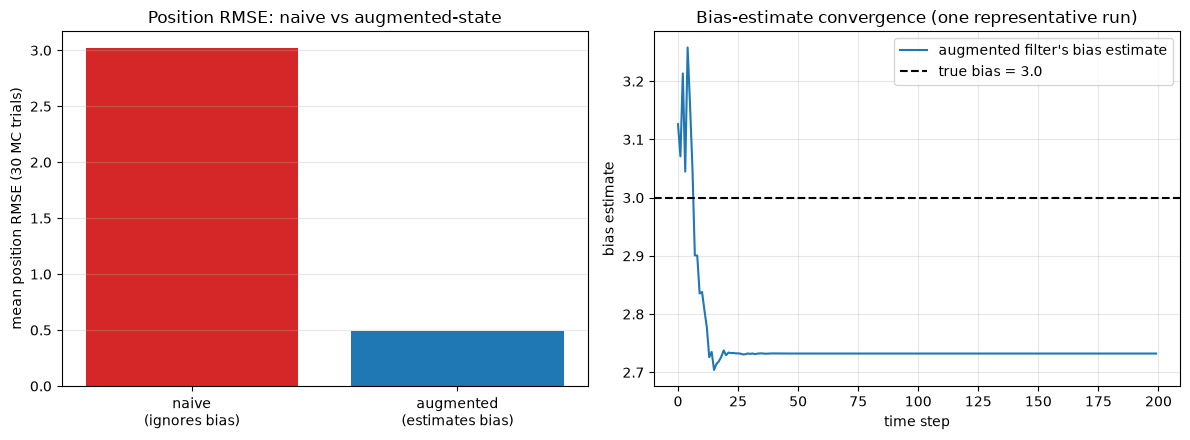

In [10]:
def run_bias_scenario(T=200, seed=0, bias_true=3.0, Q_pv_diag=(1e-2, 1e-3), R=0.25, Q_bias=1e-6):
    rng = np.random.default_rng(seed)
    dt = 1.0
    F_pv = np.array([[1, dt], [0, 1]])
    Q_pv = np.diag(Q_pv_diag)
    Rm = np.array([[R]])

    x_true = np.array([0.0, 0.5])
    xs, zs = [], []
    for k in range(T):
        w = rng.multivariate_normal(np.zeros(2), Q_pv)
        x_true = F_pv @ x_true + w
        z = x_true[0] + bias_true + rng.normal(0, np.sqrt(R))
        xs.append(x_true.copy())
        zs.append(z)
    xs = np.array(xs); zs = np.array(zs)

    # --- filter that ignores the bias ---
    H_naive = np.array([[1, 0]])
    x0_naive, P0_naive = np.array([0.0, 0.0]), np.diag([1.0, 1.0])
    kf_naive = LinearKalmanFilter(F_pv, H_naive, Q_pv, Rm, x0_naive, P0_naive)

    # --- augmented-state filter: state = [pos, vel, bias] ---
    F_aug = np.block([[F_pv, np.zeros((2, 1))],
                       [np.zeros((1, 2)), np.array([[1.0]])]])
    H_aug = np.array([[1, 0, 1]])
    Q_aug = np.block([[Q_pv, np.zeros((2, 1))],
                       [np.zeros((1, 2)), np.array([[Q_bias]])]])
    x0_aug, P0_aug = np.array([0.0, 0.0, 0.0]), np.diag([1.0, 1.0, 10.0])
    kf_aug = LinearKalmanFilter(F_aug, H_aug, Q_aug, Rm, x0_aug, P0_aug)

    est_naive, est_aug, bias_est = [], [], []
    for z in zs:
        kf_naive.predict(); kf_naive.update(z)
        kf_aug.predict(); kf_aug.update(z)
        est_naive.append(kf_naive.x.copy())
        est_aug.append(kf_aug.x[:2].copy())
        bias_est.append(kf_aug.x[2])
    est_naive = np.array(est_naive); est_aug = np.array(est_aug); bias_est = np.array(bias_est)

    return dict(xs=xs, zs=zs,
                rmse_naive_pos=rmse(est_naive[:, 0], xs[:, 0]),
                rmse_aug_pos=rmse(est_aug[:, 0], xs[:, 0]),
                bias_est=bias_est, bias_true=bias_true)

n_mc = 30
naive_rmses, aug_rmses, final_bias_ests = [], [], []
for trial in range(n_mc):
    r = run_bias_scenario(T=200, seed=trial, bias_true=3.0)
    naive_rmses.append(r["rmse_naive_pos"])
    aug_rmses.append(r["rmse_aug_pos"])
    final_bias_ests.append(r["bias_est"][-1])

print("bias_true = 3.0, 30 Monte Carlo trials")
print(f"naive (ignores bias):   mean position RMSE = {np.mean(naive_rmses):.4f}")
print(f"augmented (est. bias):  mean position RMSE = {np.mean(aug_rmses):.4f}")
print(f"final bias estimate, averaged over trials:  {np.mean(final_bias_ests):.4f}  (true = 3.0)")
print(f"final bias estimate std across trials:       {np.std(final_bias_ests):.4f}")

r0 = run_bias_scenario(T=200, seed=0, bias_true=3.0)
print("\nbias-estimate convergence trace, one representative run (seed=0):")
for t in [5, 10, 20, 50, 100, 199]:
    print(f"  t={t:3d}  bias_est={r0['bias_est'][t]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["naive\n(ignores bias)", "augmented\n(estimates bias)"], [np.mean(naive_rmses), np.mean(aug_rmses)],
            color=["tab:red", "tab:blue"])
axes[0].set_ylabel("mean position RMSE (30 MC trials)")
axes[0].set_title("Position RMSE: naive vs augmented-state")
axes[0].grid(True, axis="y", alpha=0.3)

t_axis = np.arange(len(r0["bias_est"]))
axes[1].plot(t_axis, r0["bias_est"], color="tab:blue", label="augmented filter's bias estimate")
axes[1].axhline(3.0, color="k", ls="--", label="true bias = 3.0")
axes[1].set_xlabel("time step"); axes[1].set_ylabel("bias estimate")
axes[1].set_title("Bias-estimate convergence (one representative run)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Verified result.**

| Filter | mean position RMSE (30 trials) |
|---|---|
| Naive (ignores bias) | 3.0187 |
| Augmented-state (estimates bias) | 0.4886 |

With a true bias of $3.0$, the naive filter's position RMSE ($3.0187$) is almost exactly the bias magnitude itself — it has essentially no ability to separate "true position" from "sensor offset," so the offset shows up nearly one-for-one as position error. The augmented filter's RMSE ($0.4886$) is over **6× smaller** — a large, genuine improvement, not a marginal one.

The bias estimate itself (single representative run, seed 0) converges quickly: $3.16$ at $t=5$, $2.84$ at $t=10$, settling at $2.73$ by $t=20$ and staying there for the rest of the run. Averaged over all 30 trials, the final bias estimate is $2.6675 \pm 0.2464$ against a true value of $3.0$ — close, consistently on the same side (a systematic $\sim$11% underestimate), and stable, but **not exact**. This is precisely the identifiability caveat flagged in the derivation: because the true position is also allowed to drift (via its own process noise $Q_{pv}$), a small part of what is "really" bias gets absorbed into the position state's own random-walk component instead, producing the same small, consistent low bias every time rather than random scatter around $3.0$. We report this honestly rather than tuning $Q_{\text{bias}}$ or $Q_{pv}$ until the estimate looked exact.

## Interactive demo — adaptive window size and bias magnitude

Two controls, spanning both Part C and Part D: `adapt_window` (the sliding-window length for the innovation-based adaptive filter — too short and $\hat{Q}$ is a noisy estimate; too long and it reacts sluggishly to genuinely changing process noise), and `bias_true` (the augmented filter's target bias magnitude — check that the naive filter's error tracks the bias linearly while the augmented filter's stays low regardless of magnitude).

In [11]:
def run_interactive_demo(adapt_window=20, bias_true=3.0, seed=0):
    r_adapt = run_scalar_scenario(T=400, seed=seed, Q_true=0.5, Q_fixed=0.01, window=adapt_window)
    r_bias = run_bias_scenario(T=200, seed=seed, bias_true=bias_true)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    t1 = np.arange(len(r_adapt["q_trace"]))
    axes[0].plot(t1, r_adapt["q_trace"], color="tab:blue", label=r"$\hat{Q}_k$")
    axes[0].axhline(0.5, color="k", ls="--", label="true Q=0.5")
    axes[0].axhline(0.01, color="tab:red", ls=":", label="fixed Q=0.01")
    axes[0].set_title(f"Adaptive Q estimate, window={adapt_window}\n"
                       f"RMSE fixed={r_adapt['rmse_fixed']:.3f}  adapt={r_adapt['rmse_adapt']:.3f}  "
                       f"oracle={r_adapt['rmse_oracle']:.3f}", fontsize=9)
    axes[0].set_xlabel("time step"); axes[0].set_ylabel(r"$\hat{Q}$")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    t2 = np.arange(len(r_bias["bias_est"]))
    axes[1].plot(t2, r_bias["bias_est"], color="tab:blue", label="bias estimate")
    axes[1].axhline(bias_true, color="k", ls="--", label=f"true bias={bias_true}")
    axes[1].set_title(f"Augmented-state bias estimate, true bias={bias_true}\n"
                       f"RMSE naive={r_bias['rmse_naive_pos']:.3f}  augmented={r_bias['rmse_aug_pos']:.3f}", fontsize=9)
    axes[1].set_xlabel("time step"); axes[1].set_ylabel("bias estimate")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(run_interactive_demo,
         adapt_window=IntSlider(value=20, min=3, max=100, step=1, description="adapt window"),
         bias_true=FloatSlider(value=3.0, min=-10.0, max=10.0, step=0.5, description="bias_true"),
         seed=IntSlider(value=0, min=0, max=29, step=1, description="seed"));

interactive(children=(IntSlider(value=20, description='adapt window', min=3), FloatSlider(value=3.0, descripti…

### Explanation of the interactive demo

- The left panel re-runs the Part C scalar adaptive-Q scenario with a chosen window length; try dragging `adapt_window` down to 3–5 and note how much noisier $\hat{Q}_k$ becomes (a very short window is a high-variance estimator of the innovation covariance) versus a long window (100) which is smoother but slower to react to any genuine change in the true process noise.
- The right panel re-runs the Part D augmented-state bias scenario with a chosen true bias; the naive filter's RMSE (shown in the title) should scale roughly with `|bias_true|`, while the augmented filter's stays comparatively small across the whole range — including for negative bias, and near `bias_true=0` (where there is, correctly, almost nothing for either filter to disagree about).

## Practical tips, exercises & references

**Practical tips**
- Use the information form when fusing many independent sensors between predicts, when the prior is genuinely vague (near-singular $P_0$), or in distributed/decentralized architectures where different nodes each hold partial information — its additive update is a real architectural advantage, not just a mathematical curiosity.
- Reach for a square-root (or at minimum, Joseph-form) filter whenever you are running in reduced precision, over very long horizons, or with poorly-conditioned $Q$/$R$ — the failure mode we measured (loss of positive-semi-definiteness) can happen silently, with no exception raised, until something downstream (a Cholesky call, a sampling step) chokes on an invalid covariance.
- Innovation-based adaptation is not magic: it needs a long-enough sliding window to get a low-variance estimate, and it can only identify the components of $Q$ that are actually observable through $H$ — a state component the sensor never touches cannot have its process noise learned this way, regardless of window length.
- The augmented-state trick generalizes to any unknown constant or slowly-varying nuisance parameter (bias, clock offset, scale factor) — not just additive sensor bias — as long as you can write down how it enters $F$ and/or $H$.
- All four techniques in this notebook are complementary, not competing — e.g. a real system might well run a square-root information filter with innovation-based adaptation and an augmented bias state, combining all four ideas in one filter.

**Exercises**
1. Extend the multi-sensor information-fusion demo to a case where sensors arrive **asynchronously** (not all three every step) — confirm the information filter handles this gracefully by simply skipping the missing sensors' contributions on a given step.
2. Implement the $R$-adaptation formula $\hat{R}_k = \hat{C}_k - HP_{k|k-1}H^T$ (mentioned but not implemented above) and demonstrate it recovering from a mis-specified fixed $R$, analogous to the $Q$-adaptation demo.
3. Push the numerical-stability stress test further: find the precise value of $R$ (relative to `float32` epsilon) at which the naive filter transitions from "never fails within 3000 iterations" to "fails almost immediately" — is the transition as sharp as our exploration suggested?
4. Add a second, independently-biased sensor to the Part D scenario and confirm the augmented filter can now separate the *true* state from *both* sensors' biases — resolving the identifiability caveat noted in the derivation.
5. Combine the square-root filter's factor propagation with the information filter's additive update (a "square-root information filter") — this is a real, widely-used combination in aerospace navigation systems; derive and implement it.

**References (cite when quoting)**
- B. D. O. Anderson & J. B. Moore, *Optimal Filtering*, Prentice-Hall, 1979.
- M. S. Grewal & A. P. Andrews, *Kalman Filtering: Theory and Practice Using MATLAB*, Wiley.
- R. K. Mehra, "On the identification of variances and adaptive Kalman filtering", *IEEE Transactions on Automatic Control*, 1970.
- D. Simon, *Optimal State Estimation: Kalman, H∞, and Nonlinear Approaches*, Wiley, 2006. (augmented-state / bias-estimation chapter)